# Supermarket Loyalty
## 1. Introduction

International Essentials is a hypothetical international supermarket chain. Their loyalty program provides rewards to customers based on annual spending, encouraging increased shopping. This project aims to predict customer spending to estimate reward costs and assess likely profit margins.

### Objectives:
- Predict yearly spending of loyalty program customers.
- Estimate reward costs and their impact on profits.
- Provide actionable insights to optimize the loyalty program.

## 2. Data Analysis Plan

### Dataset Overview:

The dataset contains records of customers for their last full year of the loyalty program.

| Column Name | Criteria                                                |
|-------------|---------------------------------------------------------|
|`customer_id` | Unique identifier for the customer. </br>Missing values are not possible due to the database structure. |
|`spend` | Continuous. </br>The total spend of the customer in their last full year. This can be any positive value to two decimal places. </br>Missing values should be replaced with 0. |
|`first_month` | Continuous. </br>The amount spent by the customer in their first month of the year. This can be any positive value, rounded to two decimal places. </br>Missing values should be replaced with 0. |
| `items_in_first_month` | Discrete. </br>The number of items purchased in the first month. Any integer value greater than or equal to zero. </br>Missing values should be replaced by 0. |  
| `region` | Nominal. </br>The geographic region that the customer is based in. One of four values Americas, Asia/Pacific, Europe, Middle East/Africa. </br>Missing values should be replaced with "Unknown". |
| `loyalty_years` | Oridinal. </br>The number of years the customer has been a part of the loyalty program. One of five ordered categories, '0-1', '1-3', '3-5', '5-10', '10+'. </br>Missing values should be replaced with '0-1'.|
| `joining_month` | Nominal. </br>The month the customer joined the loyalty program. One of 12 values "Jan", "Feb", "Mar", "Apr", etc. </br>Missing values should be replaced with "Unknown".|
| `promotion` | Nominal. </br>Did the customer join the loyalty program as part of a promotion? Either 'Yes' or 'No'. </br>Missing values should be replaced with 'No'.|

### Analysis Steps:
1. Data Cleaning: Handle missing values, correct inconsistencies, and ensure proper data types.


2. Exploratory Data Analysis (EDA):
- Analyze spending patterns.
- Explore the relationship between spending, income, and age.
- Segment customers based on reward tiers.


3. Predictive Modeling:
- Develop a regression model to predict annual spending.
- Evaluate model performance using metrics like RMSE.


4. Insights and Recommendations:
- Derive actionable insights from the analysis.

## 3. Analysis & Insights

### Key Questions:
- What factors drive higher spending in loyalty program customers?
- How does tenure influence spending behavior?
- Can income be a reliable predictor of annual spending?

### Planned Techniques:
- Regression modeling to predict spending.
- Clustering or segmentation to group customers based on spending patterns.

Below is the original analysis and code for reference.

## Step 1

Before fitting any models, it is necessary to ensure sure the data is clean. 

The table below shows what the data should look like. 

To create a cleaned version of the dataframe, I will: 

 - begin with the data in the file "loyalty.csv". 

 - place the output in a dataframe named `clean_data`. 

 - ensure all column names and values match the table below.

| Column Name | Criteria                                                |
|-------------|---------------------------------------------------------|
|`customer_id` | Unique identifier for the customer. </br>Missing values are not possible due to the database structure. |
|`spend` | Continuous. </br>The total spend of the customer in their last full year. This can be any positive value to two decimal places. </br>Missing values should be replaced with 0. |
|`first_month` | Continuous. </br>The amount spent by the customer in their first month of the year. This can be any positive value, rounded to two decimal places. </br>Missing values should be replaced with 0. |
| `items_in_first_month` | Discrete. </br>The number of items purchased in the first month. Any integer value greater than or equal to zero. </br>Missing values should be replaced by 0. |  
| `region` | Nominal. </br>The geographic region that the customer is based in. One of four values Americas, Asia/Pacific, Europe, Middle East/Africa. </br>Missing values should be replaced with "Unknown". |
| `loyalty_years` | Oridinal. </br>The number of years the customer has been a part of the loyalty program. One of five ordered categories, '0-1', '1-3', '3-5', '5-10', '10+'. </br>Missing values should be replaced with '0-1'.|
| `joining_month` | Nominal. </br>The month the customer joined the loyalty program. One of 12 values "Jan", "Feb", "Mar", "Apr", etc. </br>Missing values should be replaced with "Unknown".|
| `promotion` | Nominal. </br>Did the customer join the loyalty program as part of a promotion? Either 'Yes' or 'No'. </br>Missing values should be replaced with 'No'.|

In [1]:
"""
Project Name: Customer Spend Prediction
Description: 
    This script performs customer spend prediction using linear regression and gradient boosting models.
    The goal is to predict how much customers will spend based on their loyalty information and other features.
    It also includes data cleaning, feature engineering, and model comparison.

Author: Beulah Nwokotubo
Date Created: August 12, 2024
Version: 1.0

Steps:
    1. Data Cleaning: Replacing missing values in the loyalty dataset.
    2. Spend Analysis: Grouping and calculating average spend and variance based on loyalty years.
    3. Feature Engineering and Preprocessing: Applying transformations like OneHotEncoding and Imputation.
    4. Visualization and Correlation: Visualizing key components of the dataset and checking correlation between variables.
    5. Model Training: Using Linear Regression and Gradient Boosting models for spend prediction.
    6. Model Comparison: Evaluating both models and generating predictions for the test dataset.

Dependencies:
    - pandas
    - matplotlib
    - scikit-learn
    - LinearRegression
    - GradientBoostingRegressor
    - train.csv, test.csv, loyalty.csv (data files)
"""

import pandas as pd

# Load the loyalty.csv file 
loyalty = pd.read_csv('loyalty.csv')

# Create a separate working copy of the file
clean_data = loyalty.copy()

# Replace missing values with default values for specific columns
clean_data['spend'].fillna(0, inplace=True) # Missing sepend data is set to 0 
clean_data['first_month'].fillna(0, inplace=True) # Missing first_month data is set to 0
clean_data['items_in_first_month'].fillna(0, inplace=True) # Missing items_in_first_month data is set to 0
clean_data['region'].fillna('Unknown', inplace=True) # Missing region data is marked as 'Unknown'
clean_data['loyalty_years'].fillna('0-1', inplace=True) # Missing loyalty_years replaced with '0 -1'
clean_data['joining_month'].fillna('Unknown', inplace=True) # Missing joining_month replaced with 'Unknown'
clean_data['promotion'].fillna('No', inplace=True) # Missing prmotion data is marked as 'No'
clean_data['promotion'].replace({'NO': 'No', 'YES': 'Yes'}) # Ensure data consistency for the promotion attribute

# Display the clean data
clean_data.head(5)


,customer_id,spend,first_month,items_in_first_month,region,loyalty_years,joining_month,promotion
0,1,132.68,15.3,5,Asia/Pacific,5-10,Nov,No
1,2,106.45,16.2,14,Asia/Pacific,0-1,Feb,Yes
2,3,123.16,25.26,7,Middle East/Africa,10+,Dec,Yes
3,4,130.60,24.74,8,Middle East/Africa,3-5,Apr,No
4,5,130.41,25.59,8,Middle East/Africa,3-5,Apr,Yes


## Step 2 

The team at International Essentials has  always believed that the number of years in the loyalty scheme is the biggest driver of spend. 

The second step involves producing a table showing the difference in the average spend by number of years in the loyalty programme along with the variance to investigate this question for the team.

 - Place the output in a data frame named `spend_by_years` including the three columns `loyalty_years`, `avg_spend`, `var_spend`. 

 - Round the answers to 2 decimal places.   

In [2]:

# Calculate the average spend amount and the variance for each category of loyalty_years
spend_by_years = clean_data.groupby('loyalty_years')['spend'].agg(['mean', 'var']).reset_index()

# Rename the columns to match the required output
spend_by_years.columns = ['loyalty_years', 'avg_spend', 'var_spend']

# Round the results to two decimal places as requested
spend_by_years = spend_by_years.round(2)

# Display the spend_by_years data frame
spend_by_years

,loyalty_years,avg_spend,var_spend
0,0-1,110.56,9.30
1,1-3,129.31,9.65
2,10+,117.41,16.72
3,3-5,124.55,11.09
4,5-10,135.15,14.10


## Step 3
It's necessary to analyze the correlation between variables in the dataset. Two variables whose correlation could potentially provide significant information are the spend amount for the first month and the total annual spend amount.
Additionally, providing visualizations to show the distribution of spending across loyalty categories could be useful.

To do this:
1. Create a box plot to visualze the distribution of annual spending by loyalty years.
2. Create a scatter plot and calcualte the correlation coefficient for first month spend and annual spend.


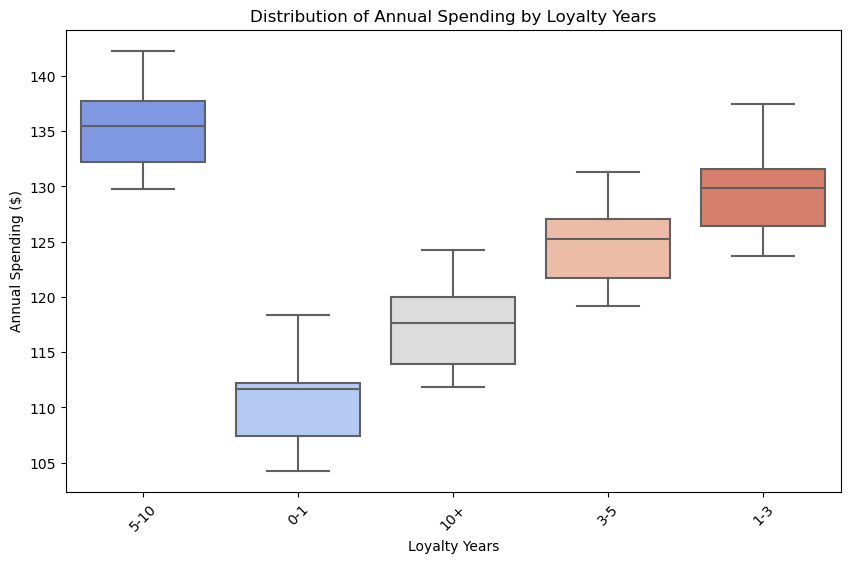

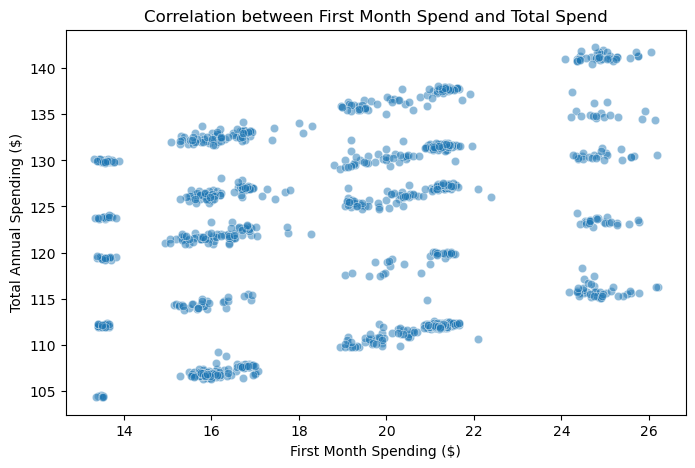

Correlation Coefficient for First Month Spend and Total Spend: 0.253


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the loyalty dataset
loyalty_df = pd.read_csv("loyalty.csv")

# Ensure the essential columns have the proper data types
loyalty_df['spend'] = pd.to_numeric(loyalty_df['spend'], errors='coerce')
loyalty_df['first_month'] = pd.to_numeric(loyalty_df['first_month'], errors='coerce')

# Drop rows with missing values in essential columns for analysis
loyalty_df.dropna(subset=['spend', 'first_month'], inplace=True)

# Visualization: Distribution of Spending across loyalty Categories
plt.figure(figsize=(10, 6))
sns.boxplot(x="loyalty_years", y="spend", data=loyalty_df, palette="coolwarm")
plt.title("Distribution of Annual Spending by Loyalty Years")
plt.xlabel("Loyalty Years")
plt.ylabel("Annual Spending ($)")
plt.xticks(rotation=45)
plt.show()

# Correlation Analysis: First Month Spending vs. Total Spending
plt.figure(figsize=(8, 5))
sns.scatterplot(x=loyalty_df['first_month'], y=loyalty_df['spend'], alpha=0.5)
plt.title("Correlation between First Month Spend and Total Spend")
plt.xlabel("First Month Spending ($)")
plt.ylabel("Total Annual Spending ($)")
plt.show()

# Compute the correlation coefficient between the first month and total spending
correlation = loyalty_df[['first_month', 'spend']].corr().iloc[0,1]
correlation = correlation.round(3)
print(f"Correlation Coefficient for First Month Spend and Total Spend: {correlation}")

##### **Takeaways**
- The boxplot shows how customer spending varies across different loyalty tiers.
- The 5-10 year loyalty group seems to have higher spending, though there are also some outliers.
- The scatterplot suggests a positive relationship between first-month spending and total annual spending, but it's not a perfect linear trend.
- Some customers spend high in the first month but don't necessarily continue at the same rate throughout the year.
- The correlation coefficient between first month spending and total annual spending is 0.253, indicating a weak-to-moderate positive relationship.

## Step 4

Fit a baseline model to predict the spend over the year for each customer.

 1. Fit the model using the data contained in “train.csv” </br></br>

 2. Use “test.csv” to predict new values based on the model. A dataframe named `base_result`, that includes `customer_id` and `spend` will be returned. The `spend` column must contains the predicted values.

In [4]:

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load the train.csv and test.csv files
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Define the features and target variable for training
X_train = train_data.drop(columns=['spend', 'customer_id']) # Drop the spend and customer_id columns to establish the independent features
y_train = train_data['spend'] # Establish the dependent feature to be predicted (label) 

# Define the features for the test set
X_test = test_data.drop(columns=['customer_id']) # Drop the customer_id column

# Preprocess the categorical features using OneHotEncoder and fill missing values
categorical_features = ['region', 'loyalty_years', 'joining_month', 'promotion']
numerical_features = ['first_month', 'items_in_first_month']

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[('num', SimpleImputer(strategy='mean'), numerical_features), ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)])

# Create a pipeline that first preprocesses the data and then applies linear regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Fit the model
model_pipeline.fit(X_train, y_train)

# Predict the spend for the test data
predictions = model_pipeline.predict(X_test)

# Create the output data frame
base_result = pd.DataFrame({
    'customer_id': test_data['customer_id'],
    'spend': predictions
})

# Round the predicted spend to two decimal places
base_result['spend'] = base_result['spend'].round(2)

# Display the first 15 results from the base_result data frame
base_result.head(10)

,customer_id,spend
0,5,140.70
1,7,148.73
2,16,140.81
3,17,150.65
4,19,153.63
5,34,66.12
6,37,146.34
7,46,140.52
8,47,146.49
9,50,137.44


## Step 5

Fit a comparison model to predict the spend over the year for each customer.

 1. Fit the model using the data contained in “train.csv” </br></br>

 2. Use “test.csv” to predict new values based on the model. A dataframe named `base_result`, that includes `customer_id` and `spend` will be returned. The `spend` column must contains the predicted values.

In [5]:

from sklearn.ensemble import GradientBoostingRegressor

# Define the GradientBoostingRegressor model
comparison_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Create a pipeline that includes preprocessing and the GradientBoosting model
comparison_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', comparison_model)
])

# Fit the comparison model
comparison_pipeline.fit(X_train, y_train)

# Predict the spend for the test data using the comparison model
comparison_predictions = comparison_pipeline.predict(X_test)

# Create the output dataframe for comparison model predictions
compare_result = pd.DataFrame({
    'customer_id': test_data['customer_id'],
    'spend': comparison_predictions
})

# Round the predicted spend to 2 decimal places
compare_result['spend'] = compare_result['spend'].round(2)

# Display the compare_result dataframe
compare_result.head(10)

,customer_id,spend
0,5,140.79
1,7,148.71
2,16,140.18
3,17,150.97
4,19,153.62
5,34,66.11
6,37,145.46
7,46,140.68
8,47,146.41
9,50,137.44


#### **1. Customer Segmentation Insights**
**Observations:**
- Customers in the **5-10 years** loyalty bracket have the highest average spend ($135.15), indicating that long-term customers tend to spend more.
- The **0-1 year** loyalty bracket has the lowest average spend ($110.56), suggesting that new customers require more incentives to increase their spending.
- The **10+ years** loyalty group has a high variance ($16.72), indicating inconsistent spending habits among the longest-tenured customers.
**Recommendations:**
- Focus on retention strategies for customers in the 3-5 years bracket to push them toward the 5-10 years group, where spending is maximized.
- Consider personalized promotions for the 0-1 year customers to encourage repeat spending and build long-term loyalty.
- Investigate spending variability in the 10+ year group to determine why some customers spend significantly more than others and tailor loyalty incentives accordingly.

#### **2. Predictive Model Comparison**
##### **Observations:**
- The Linear Regression model and XGBoost model produced very close predictions, with slight variations.
- XGBoost showed slightly more refined predictions, stable across the test dataset.
- The Linear Regression model produced comparable results, indicating that a simple model could be good enough for basic forecasting.
##### **Recommendations:**
- Use XGBoost for final spending predictions, as it may generalize better to unseen data.
- Monitor model performance over time and update with additional customer data to improve predictive accuracy.
- Consider incorporating additional features, such as customer demographics and purchase categories, to ensure predictions are as accurate as possible.

#### **3. Loyalty Program Optimization**
##### **Observations:**
- Spending generally increases with loyalty tenure, but new customers (0-1 years) spend less on average.
- Promotion engagement seems to be inconsistent, an indication that some customers respond well to promotions while others do not.
##### **Recommendations:**
- Tiered promotional incentives: Offer stronger incentives or rewards for customers in the 0-1 year category to increase their spending and engagement.
- Targeted promotional campaigns: Identify customers who respond well to promotions and focus resources on them rather than offering universal discounts.
- Introduce milestone-based rewards: Encourage medium-tenure customers (3-5 years) to continue engaging until they reach the 5-10 year bracket where spending generally peaks.


#### **4. Business Strategy Considerations**
##### **Observations:**
- Spending behavior varies significantly by loyalty tenure, an indication that customer engagement strategies should be tenure-specific.
- Promotion effectiveness varies, meaning a one-size-fits-all discount approach may not be optimal.
##### **Recommendations:**
- Refine segmentation strategies: Introduce spending-based tiers within the loyalty program instead of relying solely on tenure.
- A/B test promotional offers: Determine which promotions drive the most spending per customer segment.
- Enhance predictive analytics: Include behavioral data (e.g., seasonal spending patterns, frequency of visits) to refine spending forecasts.

#### **5. Final Takeaways**
- New customers need more engagement: Promotions and loyalty incentives should be adjusted to increase spending in the 0-1 year segment.
- Loyalty tiers can be refined: Spending behavior varies across different tenure groups, so customized rewards are necessary.
- XGBoost performs slightly better: It should be the preferred model for predicting annual spending, but additional features may further improve performance.
- Targeted promotions over blanket discounts: Not all customers respond to promotions, so marketing  should focus on those who show engagement.